# Fundamentals of Software Systems (FSS)
**Software Evolution – Part 02 Assignment**

## Submission Guidelines

To correctly complete this assignment you must:
* Carry out the assignment in a team of 2 to 4 students.
* Carry out the assignment with your team only. You are allowed to discuss solutions with other teams, but each team should come up its own personal solution. A strict plagiarism policy is going to be applied to all the artifacts submitted for evaluation.
* As your submission, upload the filled Jupyter Notebook (including outputs) together with the d3 visualization web pages (i.e. upload everything you downloaded including the filled Jupyter Notebook plus your `output.json`)
* The files must be uploaded to OLAT as a single ZIP (`.zip`) file by Dec 15, 2025 @ 23:55.


## Group Members
* Xindi, Liu, 18-214-643
* Sergi, Garcia Montmany, 24-753-980
* Ennio Jose, Fattiboni Ferrara, 25-720-277

## Task Context

In this assigment we will be analyzing the _elasticsearch_ project. All following tasks should be done with the subset of commits from tag `v0.90.0` to tag `v1.0.0.RC1`.

In [1]:
from enum import Enum
import pydriller

class Modification(Enum):
    ADDED = "Lines added"
    REMOVED = "Lines removed"
    TOTAL = "Lines added + lines removed"
    DIFF = "Lines added - lines removed"


repo = pydriller.Repository("./elasticsearch",
                            from_tag="v0.90.0",
                            to_tag="v1.0.0.RC1")

## Task 1: Author analysis

In the following, please consider only `java` files.

The first task is to get an overview of the author ownership of the _elasticsearch_ project. In particular, we want to understand who are the main authors in the system between the two considered tags, the authors distribution among files and the files distribution among authors. To this aim, perform the following:
- create a dictionary (or a list of tuples) with the pairs author => number of modified files
- create a dictionary (or a list of tuples) with the pairs file => number of authors who modified the file
- visualize the distribution of authors among files: the visualization should have on the x axis the number of authors per file (from 1 to max), and on the y axis the number of files with the given number of authors (so for example the first bar represent the number of files with single author)
- visualize the distribution of files among authors: the visualization should have on the x axis the number of files per author (from 1 to max), and on the y axis the number of authors that own the given number of files (so for example the first bar represent the minor contributors, i.e., the number of authors who own 1 file)

Comment the two distribution visualizations.



Now, let's look at the following 3 packages in more details:
1. `src/main/java/org/elasticsearch/search`
2. `src/main/java/org/elasticsearch/index`
3. `src/main/java/org/elasticsearch/action`

Create a function that, given the path of a package and a modification type (see class Modification above), returns a dictionary of authors => number, where the number counts the total lines added or removed or added+removed or added-removed (depending on the given Modification parameter), for the given package. To compute the value at the package level, you should aggregate the data per file.

Using the function defined above, visualize the author contributions (lines added + lines removed). The visualization should have the author on the x axis, and the total lines on the y axis. Sort the visualization in decreasing amount of contributions, i.e., the main author should be the first.

Compare the visualization for the 3 packages and comment.

In [2]:
# Create a dictionary (or a list of tuples) with the pair author => number of modified files
author_modified_files = {}
# Create a dictionary (or a list of tuples) with the pair file => number of authors who modified the file
file_authors = {}

for commit in repo.traverse_commits():
    # Get the author of the commit
    author = commit.author.name

    # Compute the number of modified files per author per commit
    java_files_in_commit = [f for f in commit.modified_files if f.filename and f.filename.endswith('.java')]
    
    if java_files_in_commit:
        if author not in author_modified_files:
            author_modified_files[author] = len(java_files_in_commit)
        else:
            author_modified_files[author] += len(java_files_in_commit)
    
    # Compute the number of authors per modified file (only java files)
    for modified_file in java_files_in_commit:
        filename = modified_file.filename
        if filename not in file_authors:
            file_authors[filename] = [author]
        else:
            file_authors[filename].append(author)

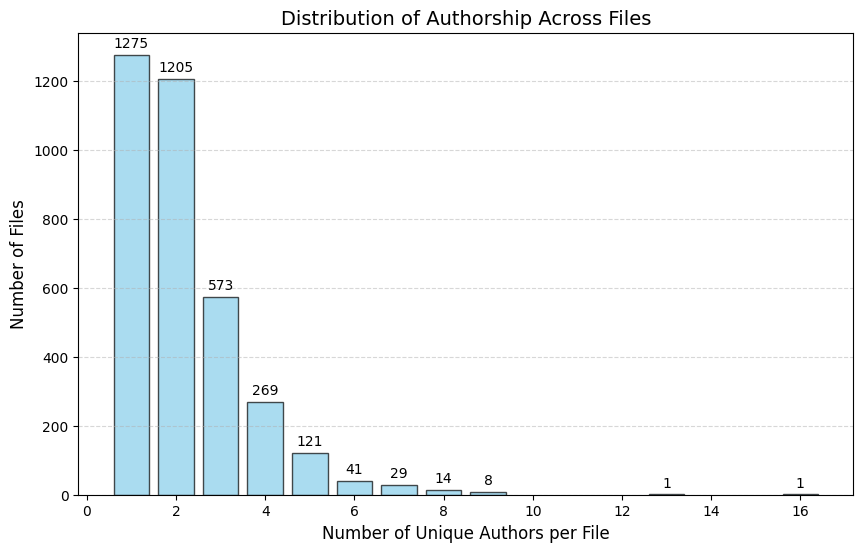

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

# we use set to ensure we count unique authors, not total commits
author_commits = [len(set(authors)) for authors in file_authors.values()]
# this counts how many files have exactly 1 author, 2 authors, etc.
author_count = Counter(author_commits)
# sort the dictionary decreasingly
x = sorted(author_count.keys())
y = [author_count[k] for k in x]

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(x, y, color='skyblue', edgecolor='black', alpha=0.7)

# styiling
plt.xlabel('Number of Unique Authors per File', fontsize=12)
plt.ylabel('Number of Files', fontsize=12)
plt.title('Distribution of Authorship Across Files', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# display values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()

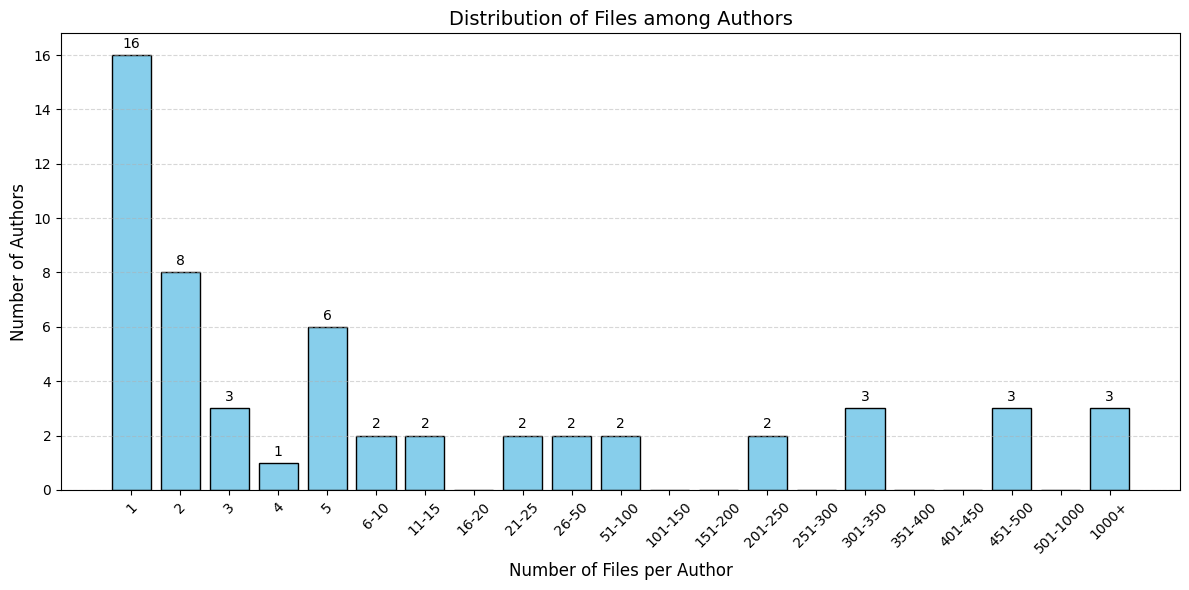

In [ ]:
# define the cut-off points: 1, 5, 10, etc.
edges = [1, 2, 3, 4, 5, 10, 15, 20, 25, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 1000]

labels = ['1', '2', '3', '4', '5', '6-10', '11-15', '16-20', '21-25', '26-50', '51-100', '101-150', '151-200', '201-250', 
          '251-300', '301-350', '351-400', '401-450', '451-500', '501-1000', '1000+']

# we create a list of zeros for each bin, plus one for the "1000+" bucket
counts_per_bin = [0] * len(labels)

file_counts = list(author_modified_files.values())

for count in file_counts:
    if count > 1000:
        counts_per_bin[-1] += 1  # put in the last "1000+" bucket
    else:
        # find which bin this count falls into
        for i in range(len(edges) - 1):
            if edges[i] <= count < edges[i+1]:
                counts_per_bin[i] += 1
                break

# plot
fig, ax = plt.subplots(figsize=(12, 6))
x_positions = range(len(labels))

bars = ax.bar(x_positions, counts_per_bin, color='skyblue', edgecolor='black')

# styling
plt.xlabel('Number of Files per Author', fontsize=12)
plt.ylabel('Number of Authors', fontsize=12)
plt.title('Distribution of Files among Authors', fontsize=14)

# replace numeric x-axis with our custom string labels
plt.xticks(x_positions, labels, rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# annotate bars
for bar in bars:
    height = bar.get_height()
    if height > 0: # only label bars that exist
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout() # Fixes cutoff labels
plt.show()

In [14]:
def compute_line_changes_from_package_path(package_path: str, modification: Modification) -> int:
    author_line_changes = {}

# consider only java files
    for commit in repo.traverse_commits():
        for modified_file in commit.modified_files:
            if modified_file.new_path and modified_file.new_path.startswith(package_path) and modified_file.new_path.endswith('.java'):
                if modification == Modification.ADDED:
                    author_line_changes[commit.author.name] = author_line_changes.get(commit.author.name, 0) + modified_file.added_lines
                elif modification == Modification.REMOVED:
                    author_line_changes[commit.author.name] = author_line_changes.get(commit.author.name, 0) + modified_file.deleted_lines
                elif modification == Modification.TOTAL:
                    author_line_changes[commit.author.name] = author_line_changes.get(commit.author.name, 0) + (modified_file.added_lines + modified_file.deleted_lines)
                elif modification == Modification.DIFF:
                    author_line_changes[commit.author.name] = author_line_changes.get(commit.author.name, 0) + (modified_file.added_lines - modified_file.deleted_lines)

    return author_line_changes

In [15]:
# total line changes per author in specific packages
changes_author_search = compute_line_changes_from_package_path("src/main/java/org/elasticsearch/search", Modification.TOTAL)
changes_author_index = compute_line_changes_from_package_path("src/main/java/org/elasticsearch/index", Modification.TOTAL)
changes_author_action = compute_line_changes_from_package_path("src/main/java/org/elasticsearch/action", Modification.TOTAL)

/var/folders/gf/0z2yd4795fn2g5229dh_57xh0000gn/T/ipykernel_84530/2642164291.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_authors, rotation=45, ha='right')
/var/folders/gf/0z2yd4795fn2g5229dh_57xh0000gn/T/ipykernel_84530/2642164291.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_authors, rotation=45, ha='right')
/var/folders/gf/0z2yd4795fn2g5229dh_57xh0000gn/T/ipykernel_84530/2642164291.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_authors, rotation=45, ha='right')


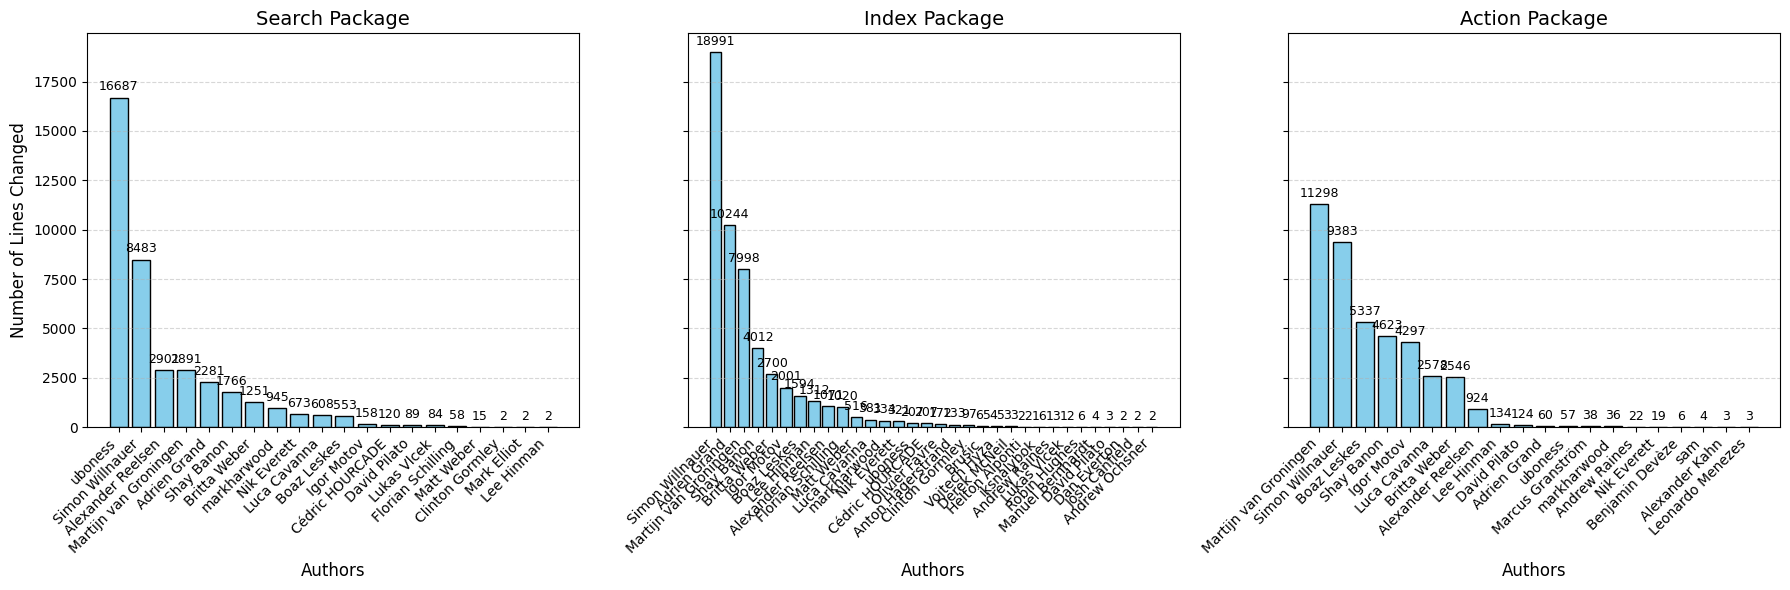

In [16]:
packages = [
    ("Search Package", changes_author_search),
    ("Index Package", changes_author_index),
    ("Action Package", changes_author_action)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# iterate through axes and data
for ax, (package_name, author_data) in zip(axes, packages):
    
    # sort authors by line count
    sorted_authors = sorted(author_data.keys(), key=lambda k: author_data[k], reverse=True)
    counts = [author_data[auth] for auth in sorted_authors]
    
    # plot
    bars = ax.bar(sorted_authors, counts, color='skyblue', edgecolor='black')
    
    # styling per subplot
    ax.set_title(package_name, fontsize=14)
    ax.set_xlabel('Authors', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # rotate x-axis labels
    ax.set_xticklabels(sorted_authors, rotation=45, ha='right')
    
    # numbers on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
            
axes[0].set_ylabel('Number of Lines Changed', fontsize=12)

plt.tight_layout()
plt.show()

## Task 2: Knowledge loss

We now want to analyze the knowledge loss when the main contributor of the analyzed project would leave. For this we will use the circle packaging layout introduced in the "Code as a Crime Scene" book. This assignment includes the necessary `knowledge_loss.html` file as well as the `d3` folder for all dependencies. You task is to create the `output.json` file according to the specification below. This file can then be visualized with the files provided.

For showing the visualization, once you have the output as `output.json` you should
* make sure to have the `knowledge_loss.html` file in the same folder
* start a local HTTP server in the same folder (e.g. with python `python3 -m http.server`) to serve the html file (necessary for d3 to work)
* open the served `knowledge_loss.html` and look at the visualization

For the package you identify as the worst in terms of knowledge loss, investigate the author contributions using the function defined in the previous exercise and comment how the situation is, e.g. how big the gap between the main author and the second biggest contributor for the selected package is.

### Output Format for Visualization

* `root` is always the root of the tree
* `size` should be the total number of lines of contribution
* `weight` can be set to the same as `size`
* `ownership` should be set to the percentage of contributions from the main author (e.g. 0.98 for 98% if contributions coming from the main author)

```
{
  "name": "root",
  "children": [
    {
      "name": "test",
      "children": [
        {
          "name": "benchmarking",
          "children": [
            {
              "author_color": "red",
              "size": "4005",
              "name": "t6726-patmat-analysis.scala",
              "weight": 1.0,
              "ownership": 0.9,
              "children": []
            },
            {
              "author_color": "red",
              "size": "55",
              "name": "TreeSetIterator.scala",
              "weight": 0.88,
              "ownership": 0.9,
              "children": []
            }
          ]
        }
      ]
    }
  ]
}
```

### JSON Export

For exporting the data to JSON you can use the following snippet:

```
import json

with open("output.json", "w") as file:
    json.dump(tree, file, indent=4)
```

In [17]:
import json
from collections import defaultdict
import hashlib


# In output.json, we track the contributions in the following way: {file name _ 1: {author: total_lines_contributed}, file name _ 2: {author: total_lines_contributed},...}
file_author_contributions = defaultdict(lambda: defaultdict(int))

# Process all commits between "v0.90.0" and "v1.0.0.RC1"
commit_count = 0
for commit in repo.traverse_commits():
    commit_count += 1
    # Get the author of the commit
    author = commit.author.name
    
    for modified_file in commit.modified_files:
        # if the path is newly created/moved or it existed before
        filepath = modified_file.new_path or modified_file.old_path
        if filepath:
            # Count total lines modified (added + deleted) as contribution
            lines_contributed = modified_file.added_lines + modified_file.deleted_lines
            file_author_contributions[filepath][author] += lines_contributed


In [18]:
# Color palette for different authors
def get_author_color(author_name):
    colors = [
        "#e6194b",  
        "#3cb44b",  
        "#ffe119",  
        "#4363d8",  
        "#f58231",  
        "#911eb4",  
        "#46f0f0",  
        "#f032e6",  
        "#bcf60c",  
        "#fabebe"   
    ]
    
    # Hash the author name to get a consistent color for the same person
    author_hash = int(hashlib.md5(author_name.encode()).hexdigest(), 16)
    color_index = author_hash % len(colors)
    
    return colors[color_index]


# Build the hierarchical tree structure for output.json file
def build_tree():

    root = {"name": "root", "children": []}

    # Key: directory path, Value: the node object
    directory_cache = {"": root}
    
    # Process each file and its author contributions
    for file_path, author_contributions in file_author_contributions.items():
        # skip in case of emptz path
        if not file_path:
            continue
        
        # Calculate total lines in this file
        total_lines = sum(author_contributions.values())
        if total_lines == 0:
            continue  # Skip empty files
        
        # Figure out who "owns" this file (wrote the most lines)
        main_author, lines_by_main_author = max(
            author_contributions.items(), 
            key=lambda item: item[1]  # Sort by line count
        )
        ownership_percentage = lines_by_main_author / total_lines
        
        # Split the file path into directories and filename -> e.g., "src/utils/helper.py" -> ["src", "utils"] + "helper.py"
        path_parts = file_path.split('/')
        filename = path_parts[-1]
        directory_parts = path_parts[:-1]
        
        # Build out the directory structure
        current_full_path = ""
        parent_node = root
        
        for directory_name in directory_parts:
            # Build the path
            current_full_path = f"{current_full_path}/{directory_name}" if current_full_path else directory_name
            
            # Create this directory if we haven't seen it before
            if current_full_path not in directory_cache:
                new_directory = {
                    "name": directory_name,
                    "children": []
                }
                parent_node["children"].append(new_directory)
                directory_cache[current_full_path] = new_directory
            
            # Move down into this directory for the next iteration
            parent_node = directory_cache[current_full_path]
        
        # Finally, add the actual file as a leaf node
        file_node = {
            "name": filename,
            "author_color": get_author_color(main_author),
            "size": total_lines,
            "weight": 1.0,  # Could be used for sizing in visualization
            "ownership": round(ownership_percentage, 2),
            "children": []  # Files don't have children, but keeping structure consistent
        }
        parent_node["children"].append(file_node)
    
    return root


# Generate and save the JSON file
tree = build_tree()

with open("output.json", "w") as output_file:
    json.dump(tree, output_file, indent=2)

print("output.json created")

output.json created


In [20]:
# Find the worst package in terms of Knowledge Loss Risk
# Recursively walks through the tree structure and calculates ownership statistics for each package
def find_risky_packages(node, path=""):
    results = []
    current = path + "/" + node["name"] if path else node["name"]
    
    # If node has children, it's a directory
    if "children" in node and node["children"]:
        total = weighted = files = 0
        for child in node["children"]:
            # Only consider files <- only files have "size"
            if "size" in child and not child["children"]:
                total += child["size"]
                weighted += child["size"] * child["ownership"]
                files += 1
        
        # Only consider packages with at least 3 files <- to avoid noise from small packages
        if files >= 3:
            results.append({
                "path": current,
                "ownership": weighted / total,
                "files": files,
                "lines": total
            })
        
        # Fetch children directories recursively
        for child in node["children"]:
            results.extend(find_risky_packages(child, current))
    
    return results
            

In [21]:
# Sort by ownership concentration (highest risk first)
all_packages = find_risky_packages(tree)
results = sorted(all_packages, key=lambda x: x['ownership'], reverse=True)

worst_with_multiple = None

for result in results:
    # Clean up the path (remove the "root/" prefix)
    package_path = result['path'].replace("root/", "")
    
    # Count up how many lines each person contributed to this package
    contributors = defaultdict(int)
    
    for file_path, author_data in file_author_contributions.items():
        # Only look at files that belong to this package
        if file_path.startswith(package_path):
            for author_name, line_count in author_data.items():
                contributors[author_name] += line_count
    
    # We need at least 2 people to have a meaningful "ownership risk"
    # (If only 1 person worked on it, of course they own 100%!)
    if len(contributors) >= 2:
        worst_package_with_team = result
        break  # Got it! No need to keep looking

In [22]:
if worst_package_with_team:
    worst = worst_package_with_team
    package_path = worst['path'].replace("root/", "")
    
    # Count how many lines each author wrote in this package
    contributors = defaultdict(int)
    for file_path, author_data in file_author_contributions.items():
        if file_path.startswith(package_path):
            for author_name, line_count in author_data.items():
                contributors[author_name] += line_count

    # Sort authors by line count (highest first)
    sorted_contributors = sorted(contributors.items(), key=lambda x: x[1], reverse=True)
    total_lines = sum(contributors.values())
    
    print(f"\n{'='*80}")
    print(f"WORST PACKAGE: {worst['path']}")
    print(f"Ownership: {worst['ownership']:.1%} | Lines: {total_lines:,} | Files: {worst['files']}")
    print(f"{'='*80}")
    
    # Show top 5 contributors
    print(f"\nTop Contributors:")
    for i, (author, lines) in enumerate(sorted_contributors[:5], 1):
        pct = lines / total_lines * 100
        print(f"{i}. {author[:30]:<30} {lines:>7,} lines ({pct:>5.1f}%)")
    
    # Gap between #1 and #2
    main_author, main_lines = sorted_contributors[0]
    second_author, second_lines = sorted_contributors[1]
    gap_ratio = main_lines / second_lines
    
    print(f"\nGap: {main_author} has {gap_ratio:.1f}x more lines than {second_author}")
    
    # Risk level: Critical when the author of the code owns more than 80% of code and 5 times of the code more than the 2 author .. 
    if worst['ownership'] > 0.8 and gap_ratio > 5:
        print("Risk: CRITICAL")
    elif worst['ownership'] > 0.6 and gap_ratio > 3:
        print("Risk: HIGH")
    elif worst['ownership'] > 0.4:
        print("Risk: MEDIUM")
    else:
        print("Risk: LOW")

else:
    print("\nNo packages found with 2+ contributors")


WORST PACKAGE: root/src/main/java/org/elasticsearch/common/lucene/store
Ownership: 100.0% | Lines: 151 | Files: 6

Top Contributors:
1. Simon Willnauer                     78 lines ( 51.7%)
2. Shay Banon                          73 lines ( 48.3%)

Gap: Simon Willnauer has 1.1x more lines than Shay Banon
Risk: MEDIUM


The worst package with multiple contributors is org/elasticsearch/common/lucene/store (151 lines). Contributors:
- Simon Willnauer: 78 lines (51.7%)
- Shay Banon: 73 lines (48.3%)

**Gap Analysis:**
The gap between Simon and Shay is small (5 lines). This means the knowledge in this package is almost evenly split between them, which is actually not bad.
Looking at the bigger picture, both are major players in the project: Simon has worked on 7,245 files total, while Shay has touched 1,658 files. So we're talking about two experienced developers who both know this package well.

**Risk Assessment: MEDIUM**
Even though individual files tend to have a single owner, the overall package knowledge is well-balanced between Simon and Shay. The tiny 1.1x gap means if one of them leaves, the other already understands nearly half the code—not ideal, but definitely manageable. There's enough overlap that the team wouldn't be starting from scratch.

For visualization run: python3 -m http.server 8000 then open http://localhost:8000/knowledge_loss.html

## Task 3: Code Churn Analysis

The third and last task is to analyze the code churn of the _elasticsearch_ project. For this analysis we look at the code churn, meaning the daily change in the total number of lines of the project. Visualize the code churn over time bucketing the data by day. Remember that you'll need to interpolate the data for days when there are no commits. Chose an interpolation strategy and justify it.

Look at the churn trend over time and identify two outliers. For each of them:
- identify if it was caused by a single or multiple commits (since you are bucketing the data by day)
- find the hash of the involved commit(s)
- find the involved files
- look at the actual diff

Based on the above, discuss if the outlier is a false positive or should be a reason for concern.

In [ ]:
from dateutil.rrule import rrule, DAILY
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, RangeTool, HoverTool

timeseries_a = defaultdict(int)
timeseries_d = defaultdict(int)
timeseries_c = defaultdict(int)

for commit in repo.traverse_commits():
    timeseries_a[commit.committer_date.date()] += commit.insertions
    timeseries_d[commit.committer_date.date()] += commit.deletions
    timeseries_c[commit.committer_date.date()] += commit.insertions - commit.deletions 

In [ ]:
def extrapolate_ts_day(timeseries, start_date, end_date):
    extrapolated_ts = []
    for dt in rrule(DAILY, dtstart=start_date, until=end_date):
        value = timeseries.get(dt.date(), 0)
        extrapolated_ts.append([dt,value])
    return extrapolated_ts

commits = list(repo.traverse_commits())

first_commit_date = commits[0].committer_date
last_commit_date = commits[-1].committer_date
full_timeseries_a = extrapolate_ts_day(timeseries_a, first_commit_date, last_commit_date)
full_timeseries_d = extrapolate_ts_day(timeseries_d, first_commit_date, last_commit_date)
full_timeseries_c = extrapolate_ts_day(timeseries_c, first_commit_date, last_commit_date)

In [ ]:
# Plot 1, code churn as insertios - deletions
data = {
    "day": [x[0] for x in full_timeseries_c],
    "churn": [x[1] for x in full_timeseries_c],
}
source = ColumnDataSource(data)

p = figure(
    height=300,
    width=980,
    tools="xpan",
    toolbar_location=None,
    x_axis_type="datetime",
    x_axis_location="above",
    background_fill_color="#efefef",
    x_range=(data["day"][1], data["day"][100]),
)
hover = HoverTool(
    tooltips=[("Day", "@day{%F}"), ("Churn", "@churn{0,0}")],
    formatters={"@day": "datetime"},  # use 'datetime' formatter for '@date' field
    mode="vline",
)
p.line("day", "churn", source=source, name="churn", line_width=2)
p.add_tools(hover)
p.yaxis.axis_label = "Code Churn (Insertions - Deletions)"

select = figure(
    title="Zoom",
    height=130,
    width=980,
    y_range=p.y_range,
    x_axis_type="datetime",
    y_axis_type=None,
    tools="",
    toolbar_location=None,
    background_fill_color="#efefef",
)

range_tool = RangeTool(x_range=p.x_range)
range_tool.overlay.fill_color = "navy"
range_tool.overlay.fill_alpha = 0.2

select.line("day", "churn", source=source)
select.ygrid.grid_line_color = None
select.add_tools(range_tool)

output_notebook()
show(column(p, select))

# Plot 2, with separate lines for addition and deletion
data = {
    "day": [x[0] for x in full_timeseries_a],
    "addition": [x[1] for x in full_timeseries_a],
    "deletion": [x[1] for x in full_timeseries_d],
}

source = ColumnDataSource(data)

p = figure(
    height=300,
    width=980,
    tools="xpan",
    toolbar_location=None,
    x_axis_type="datetime",
    x_axis_location="above",
    background_fill_color="#efefef",
    x_range=(data["day"][1], data["day"][100]),
)

hover = HoverTool(
    tooltips=[
        ("Day", "@day{%F}"),
        ("Lines added", "@addition{0,0}"),
        ("Lines removed", "@deletion{0,0}"),
    ],
    formatters={"@day": "datetime"},  # use 'datetime' formatter for '@date' field
    mode="vline",
)

p.line("day", "addition", source=source, name="addition", line_color="green", line_width=2)
p.line("day", "deletion", source=source, line_color="red", line_width=2)
p.add_tools(hover)
p.yaxis.axis_label = "Code Churn"

select = figure(
    title="Zoom",
    height=130,
    width=980,
    y_range=p.y_range,
    x_axis_type="datetime",
    y_axis_type=None,
    tools="",
    toolbar_location=None,
    background_fill_color="#efefef",
)

range_tool = RangeTool(x_range=p.x_range)
range_tool.overlay.fill_color = "navy"
range_tool.overlay.fill_alpha = 0.2

select.line("day", "addition", source=source, line_color="green")
select.line("day", "deletion", source=source, line_color="red")
select.ygrid.grid_line_color = None
select.add_tools(range_tool)

output_notebook()
show(column(p, select))

Loading BokehJS ...

Loading BokehJS ...

The interpolation strategy chosen is to put 0 insertions and deletions to the days without any commits. In this way the data is accurate. Something to note is that big code changes will appear as spikes, instead of gradual throghout many days. This may be of interest for the next section about outliers.

In [ ]:
from datetime import date

outlier1_date = date(2013, 8, 29)
outlier1_commits = []
outlier2_date = date(2013, 11, 24)
outlier2_commits = []

for commit in repo.traverse_commits():
    commit_date = commit.committer_date.date()
    if commit_date == outlier1_date:
        outlier1_commits.append(commit)
    elif commit_date == outlier2_date:
        outlier2_commits.append(commit)

def analyze_date(commits: list[pydriller.Commit]):
    if not commits or not len(commits):
        raise ValueError("commits must be a non-empty list of pydriller.Commit objects")

    files = []
    diffs = []
    hashes = []
    for c in commits:
        hashes.append(c.hash)
        for m in c.modified_files:
            files.append(m.new_path)
            diffs.append(m.diff)
    files = list(set(files))
    stats = {
        "date": commits[0].committer_date.date(),
        "number_commits": len(commits),
        "hashes": hashes,
        "number_modified_files": len(files),
        "files": files,
        "diffs": diffs,
    }
    return stats

The two identified outliers are at 2013-08-29 and at 2013-11-24. These are the two days with the highest code churn with 24,307 and 27,282 respectively. The following 4 cells show
- Date
- Number of commits
- List of hashes
- Number of modified files
- List of files
- List of diffs
- Formatted text of the 2 largest diffs, and the smallest diff

In [ ]:
outlier1_stats = analyze_date(outlier1_commits)
outlier1_stats

{'date': datetime.date(2013, 8, 29),
 'number_commits': 13,
 'hashes': ['822043347ed4151498e1405dd7494cc2c51684e9',
  'e807c99f278694af06b1895983f5daa623ec488b',
  '11ff90420a6e91e87743f59f786216678515e819',
  '5b6be0c456b9d70994887d493cb1ddc1efaf48db',
  'a1f2f44eefa812bd66546502c708ecefa26b245a',
  '25c1b93d57d86093b20844ab459803d3cb91a26c',
  '8b617fb48f1e573298a9b6a2befb14cec89ddf08',
  '649108656df1a436c8b1fba071f4191b3d404f40',
  'ffd019c07e19477b820985cf83f9bb0bc2ee0f9b',
  '76939b82d3b240e0c4c596217ceda7ee60ae0179',
  '10e55bd3ef4f14e667981b0688eaa779fe250a84',
  'f408673bd4a98e2157fa927ddb07d7d597c8ceb3',
  '7113731022ec38c1ed7d4461da78427a166cd851'],
 'number_modified_files': 339,
 'files': ['docs\\reference\\analysis\\tokenfilters\\truncate-tokenfilter.asciidoc',
  'docs\\reference\\search\\request\\fields.asciidoc',
  'docs\\reference\\search\\facets\\date-histogram-facet.asciidoc',
  'docs\\reference\\analysis\\tokenizers\\keyword-tokenizer.asciidoc',
  'docs\\reference\\i

In [ ]:
outlier1_stats = analyze_date(outlier1_commits)
outlier1_stats

{'date': datetime.date(2013, 8, 29),
 'number_commits': 13,
 'hashes': ['822043347ed4151498e1405dd7494cc2c51684e9',
  'e807c99f278694af06b1895983f5daa623ec488b',
  '11ff90420a6e91e87743f59f786216678515e819',
  '5b6be0c456b9d70994887d493cb1ddc1efaf48db',
  'a1f2f44eefa812bd66546502c708ecefa26b245a',
  '25c1b93d57d86093b20844ab459803d3cb91a26c',
  '8b617fb48f1e573298a9b6a2befb14cec89ddf08',
  '649108656df1a436c8b1fba071f4191b3d404f40',
  'ffd019c07e19477b820985cf83f9bb0bc2ee0f9b',
  '76939b82d3b240e0c4c596217ceda7ee60ae0179',
  '10e55bd3ef4f14e667981b0688eaa779fe250a84',
  'f408673bd4a98e2157fa927ddb07d7d597c8ceb3',
  '7113731022ec38c1ed7d4461da78427a166cd851'],
 'number_modified_files': 339,
 'files': ['docs\\reference\\analysis\\tokenfilters\\truncate-tokenfilter.asciidoc',
  'docs\\reference\\search\\request\\fields.asciidoc',
  'docs\\reference\\search\\facets\\date-histogram-facet.asciidoc',
  'docs\\reference\\analysis\\tokenizers\\keyword-tokenizer.asciidoc',
  'docs\\reference\\i

In [ ]:
outlier2_stats = analyze_date(outlier2_commits)
outlier2_stats

{'date': datetime.date(2013, 11, 24),
 'number_commits': 5,
 'hashes': ['c7f6c5266d15fefa1a5ce9ae7ffc519c5ff8abbe',
  '8fda8aaabfa2e99e140093d8949fdf9fc72605be',
  '28adbd475dbaa9ef689cabcc501004f05b74a8b7',
  '8e17d636ef441a9be80977d34acfaabc12982eb7',
  'e3d4d73242d215389280b1d7b9facb7b1bd9bd7d'],
 'number_modified_files': 287,
 'files': ['src\\test\\java\\org\\elasticsearch\\test\\ElasticsearchIntegrationTest.java',
  'src\\test\\java\\org\\elasticsearch\\search\\aggregations\\bucket\\NestedTests.java',
  'src\\main\\java\\org\\apache\\lucene\\store\\bytebuffer\\ByteBufferDirectory.java',
  'src\\test\\java\\org\\elasticsearch\\search\\aggregations\\metrics\\StatsTests.java',
  'pom.xml',
  'docs\\reference\\search\\aggregations\\bucket.asciidoc',
  'src\\main\\java\\org\\elasticsearch\\search\\SearchModule.java',
  'src\\main\\java\\org\\elasticsearch\\index\\codec\\PerFieldMappingPostingFormatCodec.java',
  'src\\main\\java\\org\\elasticsearch\\search\\facet\\datehistogram\\ValueD

In [ ]:
outlier2_stats = analyze_date(outlier2_commits)
outlier2_stats

{'date': datetime.date(2013, 11, 24),
 'number_commits': 5,
 'hashes': ['c7f6c5266d15fefa1a5ce9ae7ffc519c5ff8abbe',
  '8fda8aaabfa2e99e140093d8949fdf9fc72605be',
  '28adbd475dbaa9ef689cabcc501004f05b74a8b7',
  '8e17d636ef441a9be80977d34acfaabc12982eb7',
  'e3d4d73242d215389280b1d7b9facb7b1bd9bd7d'],
 'number_modified_files': 287,
 'files': ['src\\test\\java\\org\\elasticsearch\\test\\ElasticsearchIntegrationTest.java',
  'src\\test\\java\\org\\elasticsearch\\search\\aggregations\\bucket\\NestedTests.java',
  'src\\main\\java\\org\\apache\\lucene\\store\\bytebuffer\\ByteBufferDirectory.java',
  'src\\test\\java\\org\\elasticsearch\\search\\aggregations\\metrics\\StatsTests.java',
  'pom.xml',
  'docs\\reference\\search\\aggregations\\bucket.asciidoc',
  'src\\main\\java\\org\\elasticsearch\\search\\SearchModule.java',
  'src\\main\\java\\org\\elasticsearch\\index\\codec\\PerFieldMappingPostingFormatCodec.java',
  'src\\main\\java\\org\\elasticsearch\\search\\facet\\datehistogram\\ValueD

The first outlier, 2013-08-29, consists mainly of documentation as we can see the majority of the files are .asciidoc. So we can conclude it is a false positive, as it is not really code changes, but documentation changes

Meanwhile, for the second outlier, 2013-11-24, is actually a really big code commit. Most of the changes are in .java files, and from the diffs we can see they are adding a lot of new code.